In [1]:
import autoroot  # noqa: F401

In [2]:
from random import randint

import torch
from matplotlib import pyplot as plt

from src.mask_utils import maskffill, maskroll
from src.natural_cubic_spline import eval_cubic_spline_1d, fit_cubic_spline_1d
from src.smoothing_splines import weighted_smoothing_spline_1d
from src.wss_wrapper import WeightedSmoothingSpline

### Data generation


In [11]:
B = 4
L = 64
H = 32
torch.manual_seed(42)
device = "cpu"
x = (
    torch.rand(
        (B, L),
        dtype=torch.float32,
        device=device,
    )
    * 20
)
x = torch.sort(x, dim=1).values
repeat_mask = torch.rand_like(x) < 0.3
x = maskffill(x, ~repeat_mask, 1)

y_true = torch.sin(x).unsqueeze(-1).repeat(1, 1, H)
y_noisy = y_true + 0.3 * torch.randn_like(y_true, device=device)

# Add some outliers with higher noise
outlier_mask = torch.rand_like(x) < 0.1
y_noisy[outlier_mask] += torch.randn(outlier_mask.sum(), H, device=device) * 2

# Create weights - lower weights for outliers
weights = torch.ones_like(x)
weights[outlier_mask] = 0.1


Visualization

In [27]:
def visualize(x_pred, y_pred):
    # Plot for a channel of a batch element
    b = randint(0, B - 1)
    h = randint(0, H - 1)
    x_ = x[b]
    y_noisy_ = y_noisy[b, :, h]
    outlier_mask_ = outlier_mask[b]
    knots_ = x_pred[b]
    y_pred_ = y_pred[b, :, h]
    y_true_ = y_true[b, :, h]

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.scatter(x_.cpu(), y_noisy_.cpu(), label="Noisy data", alpha=0.6, c="C0")
    plt.scatter(
        x_[outlier_mask_].cpu(),
        y_noisy_[outlier_mask_].cpu(),
        color="red",
        label="Outliers",
    )
    plt.plot(
        knots_.cpu(),
        y_pred_.cpu(),
        "-",
        c="C0",
        linewidth=2,
        label="Weighted smoothing spline",
    )
    plt.plot(x_.cpu(), y_true_.cpu(), "k--", label="True function")
    plt.legend()
    plt.title("Weighted Smoothing Spline Interpolation")
    plt.show()


### Manual spline fitting

In [13]:
wsm_b = torch.vmap(weighted_smoothing_spline_1d, (0, 0, 0, 0, None))
wsm_bh = torch.vmap(wsm_b, (None, -1, None, None, None), -1)

fitspline_b = torch.vmap(fit_cubic_spline_1d)
fitspline_bh = torch.vmap(fitspline_b, (None, -1), -1)

evlspline_b = torch.vmap(eval_cubic_spline_1d)
evlspline_bh = torch.vmap(evlspline_b, (-1, None, None), -1)

/tmp/ipykernel_96168/1744181245.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(


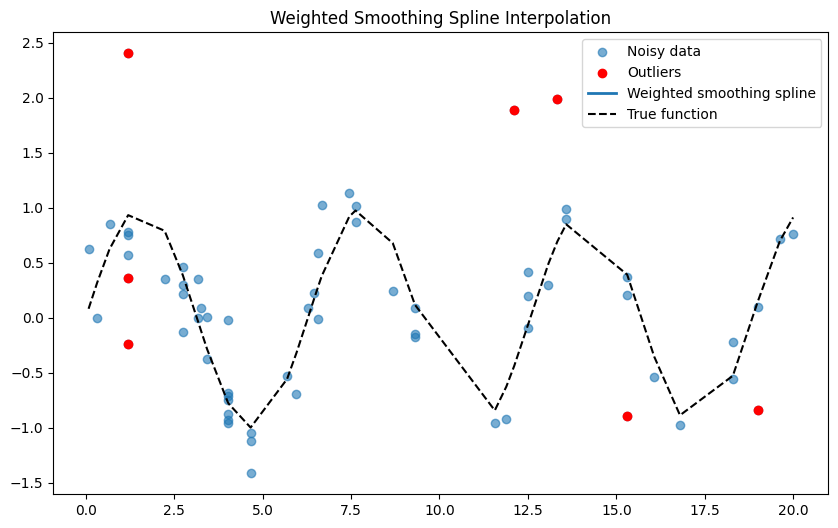

In [ ]:
# Calculate knots
knot_mask = torch.empty_like(x, dtype=bool)
knot_mask[:, :-1] = x[:, :-1] != x[:, 1:]
knot_mask[:, -1] = True
new_mask, x_pred = maskroll(knot_mask, x)
x_pred = torch.where(new_mask, x_pred, torch.inf)

# Fit the weighted smoothing spline
y_hat = wsm_bh(x, y_noisy, x_pred, weights, 1.0)
coeffs = fitspline_bh(x_pred, y_hat)

# Evaluate on new points
x_new = torch.linspace(0, 25, 200, device=device)[None].repeat(B, 1)
y_spline = torch.vmap(evlspline_bh, (None, None, 1), 1)(coeffs, x_pred, x_new)

visualize(x_new, y_spline)

### Automated fitting

In [28]:
spline = WeightedSmoothingSpline(H, 8)
spline.fit(x, y_noisy)
y_new = torch.stack([spline(x_) for x_ in x_new.unbind(1)], dim=2)

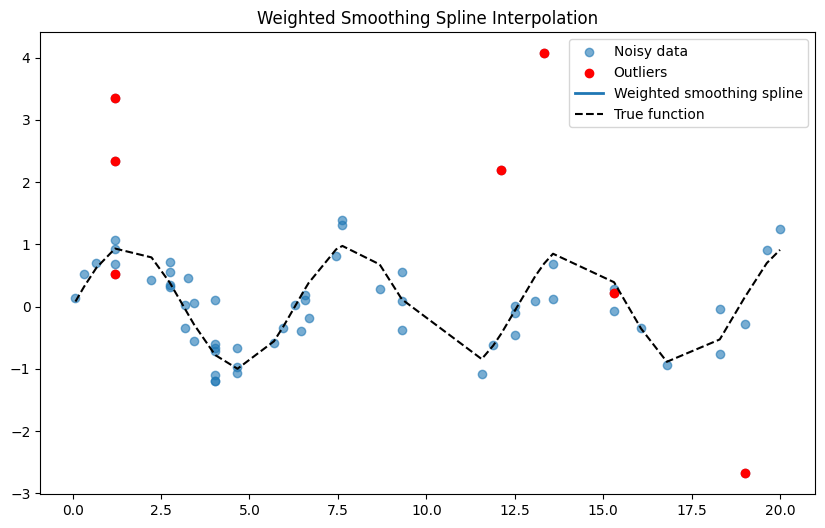

In [35]:
n = randint(0, 7)
visualize(x_new.detach(), y_new[n].detach())